# Project Overview
### Build a machine learning model to classify news as real or fake.

In [1]:
import pandas as pd
import numpy as np

## Data Description

In [2]:
df_T = pd.read_csv('True.csv')
df_F = pd.read_csv('Fake.csv')

In [3]:
df_T.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [4]:
df_F.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [5]:
df_T.info(), df_F.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21417 entries, 0 to 21416
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    21417 non-null  object
 1   text     21417 non-null  object
 2   subject  21417 non-null  object
 3   date     21417 non-null  object
dtypes: object(4)
memory usage: 669.4+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23481 entries, 0 to 23480
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    23481 non-null  object
 1   text     23481 non-null  object
 2   subject  23481 non-null  object
 3   date     23481 non-null  object
dtypes: object(4)
memory usage: 733.9+ KB


(None, None)

In [6]:
df_T.describe()

,title,text,subject,date
count,21417,21417,21417,21417
unique,20826,21192,2,716
top,Factbox: Trump fills top jobs for his administ...,(Reuters) - Highlights for U.S. President Dona...,politicsNews,"December 20, 2017"
freq,14,8,11272,182


In [7]:
df_F.describe()

,title,text,subject,date
count,23481,23481,23481,23481
unique,17903,17455,6,1681
top,MEDIA IGNORES Time That Bill Clinton FIRED His...,,News,"May 10, 2017"
freq,6,626,9050,46


In [8]:
df_T['date'].value_counts()

date
December 20, 2017      182
December 6, 2017       166
November 30, 2017      162
November 9, 2017       158
October 13, 2017       155
                      ... 
August 6, 2016           1
August 21, 2016          1
September 3, 2016        1
September 11, 2016       1
January 24, 2016         1
Name: count, Length: 716, dtype: int64

In [9]:
df_F['date'].value_counts()

date
May 10, 2017         46
May 26, 2016         44
May 6, 2016          44
May 5, 2016          44
May 11, 2016         43
                     ..
December 9, 2017      1
December 4, 2017      1
November 19, 2017     1
November 20, 2017     1
Jul 19, 2015          1
Name: count, Length: 1681, dtype: int64

In [10]:
df_T['subject'].value_counts()

subject
politicsNews    11272
worldnews       10145
Name: count, dtype: int64

In [11]:
df_F['subject'].value_counts()

subject
News               9050
politics           6841
left-news          4459
Government News    1570
US_News             783
Middle-east         778
Name: count, dtype: int64

## Data Preprocessing

### 1. Check **Duplicates**

In [12]:
df_T.duplicated().sum(), df_F.duplicated().sum()

(206, 3)

#### Remove duplicates

In [13]:
df_T.drop_duplicates(inplace=True)
df_F.drop_duplicates(inplace=True)

### 2. Check **Missing Values**

In [14]:
df_T.isna().sum(), df_F.isna().sum()

(title      0
 text       0
 subject    0
 date       0
 dtype: int64,
 title      0
 text       0
 subject    0
 date       0
 dtype: int64)

### 3. Handle *date* data type

In [15]:
import re

In [16]:
df_T['date'] = df_T['date'].astype(str).str.strip()
df_F['date'] = df_F['date'].astype(str).str.strip()

In [17]:
# Pattern for (MMM DD, YYYY) style
pattern1 = r'^[A-Za-z]{3,9} \d{1,2}, \d{4}$'

# Pattern for (DD-MMM-YY) style
pattern2 = r'^\d{1,2}-[A-Za-z]{3}-\d{2}$'

In [18]:
# Function to extract matches from a column
def extract_matches(column, pattern):
    return column.apply(lambda x: re.findall(pattern, x))

In [19]:
# Apply to both DataFrames
date_T_p1 = extract_matches(df_T['date'], pattern1)
date_T_p2 = extract_matches(df_T['date'], pattern2)

date_F_p1 = extract_matches(df_F['date'], pattern1)
date_F_p2 = extract_matches(df_F['date'], pattern2)

In [20]:
# Print results
print("df_T - MMM DD, YYYY format matches:", date_T_p1.apply(len).sum())
print("df_T - DD-MMM-YY format matches:", date_T_p2.apply(len).sum())
print("df_F - MMM DD, YYYY format matches:", date_F_p1.apply(len).sum())
print("df_F - DD-MMM-YY format matches:", date_F_p2.apply(len).sum())

df_T - MMM DD, YYYY format matches: 21211
df_T - DD-MMM-YY format matches: 0
df_F - MMM DD, YYYY format matches: 23433
df_F - DD-MMM-YY format matches: 35


In [21]:
# Flatten the list
from itertools import chain

flat_date_list = list(chain.from_iterable(date_F_p2))

In [22]:
df_F_p2 = df_F.loc[df_F['date'].isin(flat_date_list), 'date']
df_F_p2.value_counts()

date
15-Feb-18    9
16-Feb-18    8
18-Feb-18    7
17-Feb-18    7
19-Feb-18    3
14-Feb-18    1
Name: count, dtype: int64

In [23]:
df_F_p2 = df_F_p2.map({
    '14-Feb-18': 'February 14, 2018',
    '15-Feb-18': 'February 15, 2018',
    '16-Feb-18': 'February 16, 2018',
    '17-Feb-18': 'February 17, 2018',
    '18-Feb-18': 'February 18, 2018',
    '19-Feb-18': 'February 19, 2018'
})

In [24]:
df_F.loc[df_F['date'].isin(flat_date_list), 'date'] = df_F_p2

In [25]:
date_F_p1 = extract_matches(df_F['date'], pattern1)
date_F_p2 = extract_matches(df_F['date'], pattern2)

print("df_F - MMM DD, YYYY format matches:", date_F_p1.apply(len).sum())
print("df_F - DD-MMM-YY format matches:", date_F_p2.apply(len).sum())

df_F - MMM DD, YYYY format matches: 23468
df_F - DD-MMM-YY format matches: 0


#### Check **abbreviations**

In [26]:
# pd.set_option('display.max_rows', 15000)

In [27]:
mask_abb_format = df_F['date'].astype(str).str.match(r'^[A-Za-z]{3} \d{1,2}, \d{4}$')

# Filter rows with invalid date formats
abb_dates = df_F.loc[mask_abb_format, 'date']
print(abb_dates)

1310     May 31, 2017
1311     May 31, 2017
1312     May 31, 2017
1313     May 31, 2017
1314     May 31, 2017
             ...     
23361     May 4, 2016
23362     May 4, 2016
23363     May 3, 2016
23364     May 3, 2016
23365     May 1, 2016
Name: date, Length: 13742, dtype: object


In [28]:
# pd.reset_option('display.max_rows')

#### convert **abbreviations** to full name

In [29]:
# Mapping of abbreviated month names to full names
month_map = {
    'Jan': 'January',
    'Feb': 'February',
    'Mar': 'March',
    'Apr': 'April',
    'May': 'May',
    'Jun': 'June',
    'Jul': 'July',
    'Aug': 'August',
    'Sep': 'September',
    'Oct': 'October',
    'Nov': 'November',
    'Dec': 'December'
}

# Replace abbreviated months with full month names using regex and case-insensitive match
for abbr, full in month_map.items():
    df_F['date'] = df_F['date'].str.replace(rf'\b{abbr}\b', full, regex=True)

In [30]:
mask_abb_format = df_F['date'].astype(str).str.match(r'^[A-Za-z]{3} \d{1,2}, \d{4}$')

# Filter rows with invalid date formats
abb_dates = df_F.loc[mask_abb_format, 'date']
print(abb_dates)

1310     May 31, 2017
1311     May 31, 2017
1312     May 31, 2017
1313     May 31, 2017
1314     May 31, 2017
             ...     
23361     May 4, 2016
23362     May 4, 2016
23363     May 3, 2016
23364     May 3, 2016
23365     May 1, 2016
Name: date, Length: 2177, dtype: object


#### Check **invalid** format

In [31]:
mask_invalid_format = ~df_F['date'].astype(str).str.match(r'^[A-Za-z]{3,9} \d{1,2}, \d{4}$')

# Filter rows with invalid date formats
invalid_dates = df_F.loc[mask_invalid_format, 'date']
print(invalid_dates)

9358     https://100percentfedup.com/served-roy-moore-v...
15507    https://100percentfedup.com/video-hillary-aske...
15508    https://100percentfedup.com/12-yr-old-black-co...
15839    https://fedup.wpengine.com/wp-content/uploads/...
15840    https://fedup.wpengine.com/wp-content/uploads/...
17432    https://fedup.wpengine.com/wp-content/uploads/...
17433    https://fedup.wpengine.com/wp-content/uploads/...
18933    MSNBC HOST Rudely Assumes Steel Worker Would N...
21869    https://fedup.wpengine.com/wp-content/uploads/...
21870    https://fedup.wpengine.com/wp-content/uploads/...
Name: date, dtype: object


In [32]:
df_invalid = df_F.loc[mask_invalid_format]
df_invalid

,title,text,subject,date
9358,https://100percentfedup.com/served-roy-moore-v...,https://100percentfedup.com/served-roy-moore-v...,politics,https://100percentfedup.com/served-roy-moore-v...
15507,https://100percentfedup.com/video-hillary-aske...,https://100percentfedup.com/video-hillary-aske...,politics,https://100percentfedup.com/video-hillary-aske...
15508,https://100percentfedup.com/12-yr-old-black-co...,https://100percentfedup.com/12-yr-old-black-co...,politics,https://100percentfedup.com/12-yr-old-black-co...
15839,https://fedup.wpengine.com/wp-content/uploads/...,https://fedup.wpengine.com/wp-content/uploads/...,politics,https://fedup.wpengine.com/wp-content/uploads/...
15840,https://fedup.wpengine.com/wp-content/uploads/...,https://fedup.wpengine.com/wp-content/uploads/...,politics,https://fedup.wpengine.com/wp-content/uploads/...
17432,https://fedup.wpengine.com/wp-content/uploads/...,https://fedup.wpengine.com/wp-content/uploads/...,Government News,https://fedup.wpengine.com/wp-content/uploads/...
17433,https://fedup.wpengine.com/wp-content/uploads/...,https://fedup.wpengine.com/wp-content/uploads/...,Government News,https://fedup.wpengine.com/wp-content/uploads/...
18933,Homepage,[vc_row][vc_column width= 1/1 ][td_block_trend...,left-news,MSNBC HOST Rudely Assumes Steel Worker Would N...
21869,https://fedup.wpengine.com/wp-content/uploads/...,https://fedup.wpengine.com/wp-content/uploads/...,left-news,https://fedup.wpengine.com/wp-content/uploads/...
21870,https://fedup.wpengine.com/wp-content/uploads/...,https://fedup.wpengine.com/wp-content/uploads/...,left-news,https://fedup.wpengine.com/wp-content/uploads/...


#### Drop **invalid** format

In [33]:
df_F = df_F.loc[~mask_invalid_format]

In [34]:
mask_invalid_format = ~df_F['date'].astype(str).str.match(r'^[A-Za-z]{3,9} \d{1,2}, \d{4}$')

# Filter rows with invalid date formats
invalid_dates = df_F.loc[mask_invalid_format, 'date']
print(invalid_dates)

Series([], Name: date, dtype: object)


#### Convert **date** type to **datetime**

In [35]:
df_T['date'] = pd.to_datetime(df_T['date'])

In [36]:
df_F['date'] = pd.to_datetime(df_F['date'])

In [37]:
df_T.info(), df_F.info()

<class 'pandas.core.frame.DataFrame'>
Index: 21211 entries, 0 to 21416
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   title    21211 non-null  object        
 1   text     21211 non-null  object        
 2   subject  21211 non-null  object        
 3   date     21211 non-null  datetime64[ns]
dtypes: datetime64[ns](1), object(3)
memory usage: 828.6+ KB
<class 'pandas.core.frame.DataFrame'>
Index: 23468 entries, 0 to 23480
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   title    23468 non-null  object        
 1   text     23468 non-null  object        
 2   subject  23468 non-null  object        
 3   date     23468 non-null  datetime64[ns]
dtypes: datetime64[ns](1), object(3)
memory usage: 916.7+ KB


(None, None)

## Exploratory Data Analysis (EDA)

In [38]:
df_T.head(10)

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,2017-12-31
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,2017-12-29
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,2017-12-31
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,2017-12-30
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,2017-12-29
5,"White House, Congress prepare for talks on spe...","WEST PALM BEACH, Fla./WASHINGTON (Reuters) - T...",politicsNews,2017-12-29
6,"Trump says Russia probe will be fair, but time...","WEST PALM BEACH, Fla (Reuters) - President Don...",politicsNews,2017-12-29
7,Factbox: Trump on Twitter (Dec 29) - Approval ...,The following statements were posted to the ve...,politicsNews,2017-12-29
8,Trump on Twitter (Dec 28) - Global Warming,The following statements were posted to the ve...,politicsNews,2017-12-29
9,Alabama official to certify Senator-elect Jone...,WASHINGTON (Reuters) - Alabama Secretary of St...,politicsNews,2017-12-28


In [39]:
df_F.head(10)

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,2017-12-31
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,2017-12-31
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,2017-12-30
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,2017-12-29
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,2017-12-25
5,Racist Alabama Cops Brutalize Black Boy While...,The number of cases of cops brutalizing and ki...,News,2017-12-25
6,"Fresh Off The Golf Course, Trump Lashes Out A...",Donald Trump spent a good portion of his day a...,News,2017-12-23
7,Trump Said Some INSANELY Racist Stuff Inside ...,In the wake of yet another court decision that...,News,2017-12-23
8,Former CIA Director Slams Trump Over UN Bully...,Many people have raised the alarm regarding th...,News,2017-12-22
9,WATCH: Brand-New Pro-Trump Ad Features So Muc...,Just when you might have thought we d get a br...,News,2017-12-21


In [40]:
df_T['subject'].value_counts()

subject
politicsNews    11220
worldnews        9991
Name: count, dtype: int64

In [41]:
df_F['subject'].value_counts()

subject
News               9050
politics           6833
left-news          4456
Government News    1568
US_News             783
Middle-east         778
Name: count, dtype: int64

In [42]:
df_T.describe()

,date
count,21211
mean,2017-06-02 21:00:01.527509248
min,2016-01-13 00:00:00
25%,2017-01-27 00:00:00
50%,2017-09-12 00:00:00
75%,2017-11-02 00:00:00
max,2017-12-31 00:00:00


In [43]:
df_T.describe(include='object')

,title,text,subject
count,21211,21211,21211
unique,20826,21192,2
top,Factbox: Trump fills top jobs for his administ...,"CHARLESTON, S.C. (Reuters) - Long viewed by th...",politicsNews
freq,14,2,11220


In [44]:
df_F.describe()

,date
count,23468
mean,2016-10-07 23:30:54.917334272
min,2015-03-31 00:00:00
25%,2016-04-06 00:00:00
50%,2016-10-14 00:00:00
75%,2017-04-15 00:00:00
max,2018-02-19 00:00:00


In [45]:
df_F.describe(include='object')

,title,text,subject
count,23468,23468,23468
unique,17897,17449,6
top,MEDIA IGNORES Time That Bill Clinton FIRED His...,,News
freq,6,626,9050


#### Compare Date Ranges and Overlap

In [46]:
# Intersection of dates
common_dates = set(df_T['date']) & set(df_F['date'])
print(f"Common dates: {len(common_dates)}")

# Unique to each
unique_T = set(df_T['date']) - set(df_F['date'])
unique_F = set(df_F['date']) - set(df_T['date'])
print(f"Dates only in df_T: {len(unique_T)}")
print(f"Dates only in df_F: {len(unique_F)}")

Common dates: 716
Dates only in df_T: 0
Dates only in df_F: 294


### Combine data

In [47]:
# Label source
df_T['source'] = 'T'
df_F['source'] = 'F'

# Combine
df = pd.concat([df_T, df_F])
df

,title,text,subject,date,source
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,2017-12-31,T
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,2017-12-29,T
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,2017-12-31,T
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,2017-12-30,T
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,2017-12-29,T
...,...,...,...,...,...
23476,McPain: John McCain Furious That Iran Treated ...,21st Century Wire says As 21WIRE reported earl...,Middle-east,2016-01-16,F
23477,JUSTICE? Yahoo Settles E-mail Privacy Class-ac...,21st Century Wire says It s a familiar theme. ...,Middle-east,2016-01-16,F
23478,Sunnistan: US and Allied ‘Safe Zone’ Plan to T...,Patrick Henningsen 21st Century WireRemember ...,Middle-east,2016-01-15,F
23479,How to Blow $700 Million: Al Jazeera America F...,21st Century Wire says Al Jazeera America will...,Middle-east,2016-01-14,F


In [48]:
df.reset_index(drop=True, inplace=True)

In [49]:
df['subject'].value_counts()

subject
politicsNews       11220
worldnews           9991
News                9050
politics            6833
left-news           4456
Government News     1568
US_News              783
Middle-east          778
Name: count, dtype: int64

#### Analyze by Time

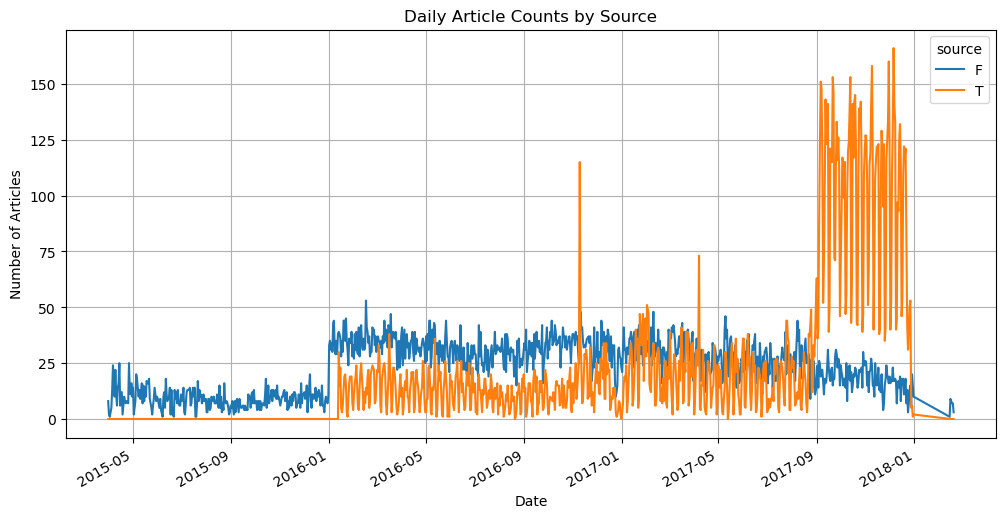

In [50]:
# Group by date
daily_counts = df.groupby(['date', 'source']).size().unstack(fill_value=0)

# Plot
import matplotlib.pyplot as plt
daily_counts.plot(figsize=(12, 6), title='Daily Article Counts by Source')
plt.xlabel('Date')
plt.ylabel('Number of Articles')
plt.grid()
plt.show()

#### Topic Distribution or Trends

<Axes: title={'center': 'Top Subjects Over Time'}, xlabel='month'>

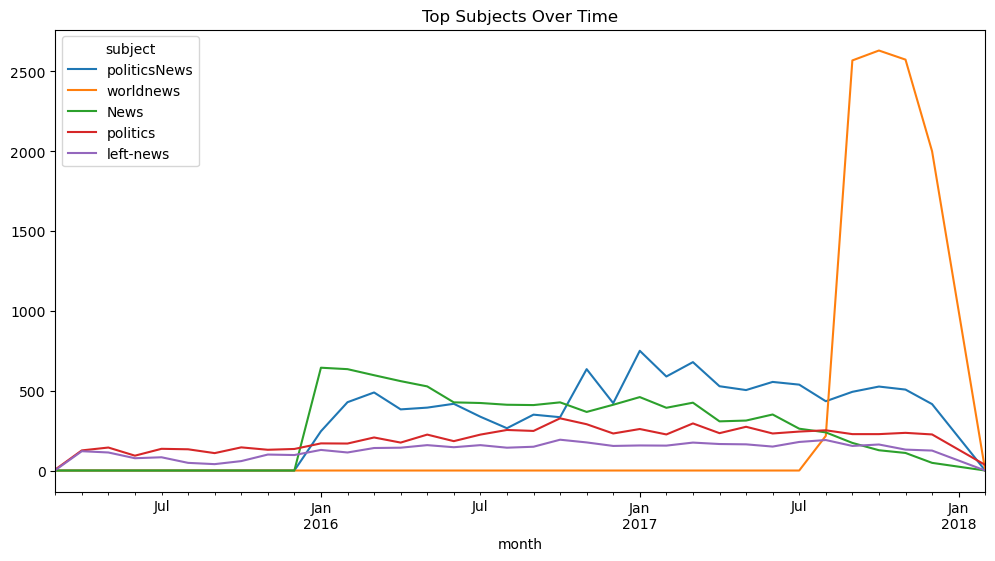

In [51]:
# count per subject per month
df['month'] = df['date'].dt.to_period('M')
subject_monthly = df.groupby(['month', 'subject']).size().unstack(fill_value=0)

# Plot top N subjects over time
top_subjects = subject_monthly.sum().sort_values(ascending=False).head(5).index
subject_monthly[top_subjects].plot(figsize=(12, 6), title='Top Subjects Over Time')

# Natural Language Processing (NLP)

In [52]:
import nltk

In [53]:
# nltk.download('punkt')
# nltk.download('stopwords')
# nltk.download('wordnet')
# nltk.download('omw-1.4')  # for lemmatizer to work properly

## Text Preprocessing

#### Combine **title** and **text** into one column

In [54]:
df['content'] = df['title'] + " " + df['text']

# Drop unused columns
df = df[['content', 'source']]

### Why Combine `title` with `text` for Modeling

- **Complementary information:**  
  The title often provides a concise summary or highlights key points, while the main text contains detailed information. Combining both enriches the input data.

- **Improves context and relevance:**  
  Some important keywords or concepts appear only in the title or only in the text. Merging them ensures the model captures the full context.

- **Better feature representation:**  
  More text means more features (words/phrases) for the model to learn patterns from, which can improve classification or prediction accuracy.

- **Addresses sparsity:**  
  Titles alone might be too short and lack sufficient information, and text alone might miss the headline’s summary effect. Combining both reduces this issue.

- **Common practice in NLP tasks:**  
  Many text classification tasks concatenate titles and bodies to leverage all available textual data effectively.

---

**Summary:**  
Combining `title` and `text` provides a richer, more complete representation of the content, helping models learn more accurate and robust patterns for tasks like classification.


### Why Not Choose `date` or `subject` as Model Features

#### `date`
- **Usually not directly useful** for text content modeling or classification tasks.
- Might add noise if the model isn’t designed to learn temporal patterns.
- Requires special preprocessing or feature engineering (e.g., extract day/month/year, convert to numeric).
- Often irrelevant if the goal is to classify or analyze the text itself rather than trends over time.

#### `subject`
- Typically the **target label** in classification tasks (e.g., news category).
- Including `subject` as an input feature leads to **data leakage** — the model could just memorize the label.
- Using it as input defeats the purpose of training a model to predict the subject from the text.
- If you want to use it as input, it must be for a different task or with proper encoding as an auxiliary feature, not as the main predictor.

---

**Summary:**  
`date` is usually excluded because it doesn’t directly contribute to understanding text content without extra processing, and `subject` is excluded because it’s the label the model is supposed to predict, so including it would cause data leakage.

#### Map **source** to **binary** label

In [55]:
df = df.copy()  # to Warning
df['label'] = df['source'].map({'T': 0, 'F': 1})  # 0 = real, 1 = fake

# df.loc[:, 'label'] = df['source'].map({'T': 0, 'F': 1})

df = df.drop('source', axis=1)

In [56]:
df.head()

,content,label
0,"As U.S. budget fight looms, Republicans flip t...",0
1,U.S. military to accept transgender recruits o...,0
2,Senior U.S. Republican senator: 'Let Mr. Muell...,0
3,FBI Russia probe helped by Australian diplomat...,0
4,Trump wants Postal Service to charge 'much mor...,0


In [57]:
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk import word_tokenize
import re
import string

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def custom_preprocessor(text):
    # Remove punctuation and numbers
    text = re.sub(r'\d+', '', text)  # Remove digits
    text = text.translate(str.maketrans('', '', string.punctuation))  # Remove punctuation
    text = text.lower()  # Lowercase
    words = word_tokenize(text)  # Tokenize
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words and len(word) > 2]
    return " ".join(words)

#### Train-Test Split

In [58]:
from sklearn.model_selection import train_test_split

X = df['content']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Text Vectorization (TF-IDF)

#### ✅ What it **does** by default:
| Step               | Performed? | Notes                                                      |
|--------------------|------------|------------------------------------------------------------|
| Lowercasing        | ✅ Yes     | Done automatically                                         |
| Tokenization       | ✅ Yes     | Uses a simple regex-based tokenizer (not as advanced as NLTK or spaCy) |
| Stop word removal  | ✅ Yes     | English stopwords removed (`stop_words='english'`)         |
| TF-IDF weighting   | ✅ Yes     | Computes term frequency & inverse document frequency       |

---

#### ❌ What it **does not do** by default:
| Step               | Performed? | Notes                                                      |
|--------------------|------------|------------------------------------------------------------|
| Lemmatization      | ❌ No      | Requires external libraries like NLTK or spaCy              |
| Stemming           | ❌ No      | Requires libraries like NLTK (e.g., PorterStemmer)          |
| Punctuation removal| ⚠️ Partial | Most punctuation is ignored due to token pattern, but not all |
| Number removal     | ⚠️ Optional| By default numbers are included; can be controlled by `token_pattern` |


In [59]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(stop_words='english', max_df=0.7)
# vectorizer = TfidfVectorizer(preprocessor=custom_preprocessor)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

## Modelling

### Model Training (e.g., Logistic Regression)

In [60]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

model = LogisticRegression()
model.fit(X_train_vec, y_train)

# Predictions
y_pred = model.predict(X_test_vec)

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9865711727842436
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      4249
           1       0.99      0.99      0.99      4687

    accuracy                           0.99      8936
   macro avg       0.99      0.99      0.99      8936
weighted avg       0.99      0.99      0.99      8936



#### Save Model

In [61]:
import joblib

# Save model and vectorizer
joblib.dump(vectorizer, 'tfidf_vectorizer.pkl')
joblib.dump(model, 'fake_news_model.pkl')

['fake_news_model.pkl']